### CEBRA 1 channel EMG model
Conditional: delta

Dataset info:

① EMG: Contains the EMG data as a numpy array of shape (360, 12, t), where t represents the number of time points corresponding to the 2-second gesture duration (either 4000 or 4296 samples, depending on whether the sampling frequency was 2000 Hz or 2148 Hz). The dataset includes 360 trials from each subject, distributed across six sessions with 60 trials per session. EMG was recorded from 12 electrodes (refer to Fig. 2 for electrode placement).

② Labels: A numpy array of shape (360,) containing gesture labels corresponding to each trial in the EMG data.

③ Frequency: An integer specifying the sampling frequency of the EMG data (2000 Hz or 2148 Hz).

④ Physiology: A nested dictionary that includes demographic and physiological data for each subject:

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import cebra
import neurokit2 as nk
from sklearn.preprocessing import StandardScaler
from cebra import CEBRA
import pickle
import pandas as pd

In [13]:
# read example pickle file and inspect the data

with open("1.pkl", "rb") as f:
    data = pickle.load(f)

type(data)
print(data.keys()) 

print("EMG info:") 
print(type(data['EMG']))
print(data['EMG'].shape)  

print("Labels info:") 
print(type(data['Labels']))
print(data['Labels'][:10])
print(set(data['Labels']))  

print("Freq info:") 
fs = data['Frequency']
print("Sampling frequency:", fs)

print("Physiology info:") 
print(data['Physiology'])


dict_keys(['EMG', 'Labels', 'Frequency', 'Physiology'])
EMG info:
<class 'numpy.ndarray'>
(360, 12, 4000)
Labels info:
<class 'numpy.ndarray'>
[2. 8. 3. 0. 1. 6. 7. 5. 9. 4.]
{0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0}
Freq info:
Sampling frequency: 2000
Physiology info:
{'Age': 86, 'Height': 177.8, 'Weight': 95.25, 'Skin_Hydration': 13.7, 'Skin_Elasticity': 36, 'Subcutaneous_Fat': array([None, None, None, None], dtype=object), 'Hair_Density': array([0, 10], dtype=object), 'Sex': 'M'}


Functions 

In [14]:
def load_emg_dataset_from_pkl(pkl_path):

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    
    # Extract fields
    emg_raw = data['EMG'] # shape: (num_trials, num_channels, time_points) (360, 12, 4000)
    labels = data['Labels'] # shape: (360,)
    fs = data['Frequency'] 
    
    # Choose a specific channel 
    channel_idx = 0
    emg_single_channel = emg_raw[:, channel_idx, :]  # shape (360, 4000)

    # Create a DataFrame: each row is a trial
    df = pd.DataFrame(emg_single_channel)
    df['label'] = labels  # Add the label as the last column

    # Save to CSV
    df.to_csv('emg_channel0_with_labels.csv', index=False)

    print(f"EMG shape (trials, samples): {emg_single_channel.shape}")
    print(f"Labels shape (trials): {labels.shape}")
    print(f"Sampling frequency: {fs} Hz")
    
    return emg_single_channel, labels, fs

In [33]:
def get_label_mapping():
    return {
        1: "Down",
        2: "Index finger pinch",
        3: "Left",
        4: "Middle finger pinch",
        5: "Index point",
        6: "Power grasp",
        7: "Right",
        8: "Two finger pinch",
        9: "Up",
        10: "Splay"
    }

In [ ]:
def segment_trial_windows(emg_trials, labels, window_size, step_size):
    """
    Segment one channel EMG signals into overlapping windows
    Each window is a sample for training
    Each window extracted from a trial inherits that trial's label
    """

    X = []
    y = []

    for trial_idx in range(len(emg_trials)):
        trial = emg_trials[trial_idx]  # shape: (4000,) for single channel

        # Shift label from 0–9 → 1–10 (needed for compatibility)
        label = int(labels[trial_idx]) + 1

        # Reshape to 2D for StandardScaler: shape (4000, 1)
        trial_reshaped = trial.reshape(-1, 1)
        trial_norm = StandardScaler().fit_transform(trial_reshaped) # mean of 0 and a sd of 1
        trial_norm = trial_norm.flatten()   # back to 1D

        # Segment into overlapping windows
        for start in range(0, len(trial_norm) - window_size, step_size):
            end = start + window_size
            window = trial_norm[start:end]  # shape: (window_size,)
            X.append(window)
            y.append(label)

    # Return as arrays
    return np.array(X), np.array(y)  # X.shape = (n_windows, window_size), y.shape = (n_windows,)

In [25]:
def prepare_cebra_dataset(X, y):
    """
    CEBRA expects input as (n_samples, n_features)
    n_samples = number of input windows or example
    n_features = number of input dimensions per sample
    Flattening turns each EMG window into a point in high-dimensional space
    CEBRA learns to project those points into a low-dimensional embedding that represents each dorsiflexion phase
    """
    
    n_windows = X.shape[0]
    X_cebra = X.reshape(n_windows, -1) # shape (n_windows, window_size)
    y_cebra = y

    return X_cebra , y_cebra

In [26]:
# Define a CEBRA model
cebra_model = CEBRA(
    model_architecture="offset10-model", # bring together time points that are 10 steps apart in the sequence
    batch_size=256,
    learning_rate=3e-4,
    temperature=1, # controls softness of the similarity distribution in the contrastive loss *Lower = sharper contrast 
    max_iterations=5000, # optimization steps
    conditional='delta', # use class labels
    output_dimension=3,
    distance='cosine', # good for contrastive learning
    device="cuda_if_available",
    verbose=True,
    time_offsets=10 # distance (in time) between positive pairs
)

Model pipeline

In [16]:
# 1. Load EMG
emg_trials, labels, fs = load_emg_dataset_from_pkl("1.pkl")

EMG shape (trials, samples): (360, 4000)
Labels shape (trials): (360,)
Sampling frequency: 2000 Hz


In [27]:
# 2. Segment and prepare EMG data

window_size = int(0.250 * fs)  # For EMG gesture recognition, usually 150–300 ms windows = 500 samples
step_size = window_size // 2 # half the window size for overlapping windows

X_win, y_win = segment_trial_windows(emg_trials, labels, window_size, step_size)

X_cebra, y_cebra = prepare_cebra_dataset(X_win, y_win)

print(f"EMG window shape (n_windows, window_size): {X_win.shape}")
print(f"Label window shape (n_windows,): {y_win.shape}")

print(f"Model input:")
print(f"Flat EMG shape (n_windows, window_size*n_channels): {X_cebra.shape}")
print(f"Labels shape (n_windows,): {y_cebra.shape}")


EMG window shape (n_windows, window_size): (5040, 500)
Label window shape (n_windows,): (5040,)
Model input:
Flat EMG shape (n_windows, window_size*n_channels): (5040, 500)
Labels shape (n_windows,): (5040,)


In [28]:
# 3. Train CEBRA model
cebra_emg_model = cebra_model.fit(X_cebra, y_cebra)
cebra_emg_model.save("emg_1channel_trial1.pt")

pos: -0.9709 neg:  5.9900 total:  5.0191 temperature:  1.0000: 100%|██████████| 5000/5000 [03:37<00:00, 23.01it/s]


In [29]:
# 4. Get the 3D embeddings for each EMG segment — used for classification
embeddings = cebra_model.transform(X_cebra)
print(f"EMG embeddings shape: {embeddings.shape}")

EMG embeddings shape: (5040, 3)


In [30]:
# 5. Calculate the Goodness of Fit (GoF) 
"""
GoF = How well do the learned embeddings separate dorsiflexion movement phases 
# Internally the function transforms X_cebra to embeddings, then checks how well they align with y_cebra
In general: 
- Low (or negative) value means the embedding is basically random with respect to the class labels
- GoF > 1.0 is considered meaningful
"""
 
gof_emg_model = cebra.sklearn.metrics.goodness_of_fit_score(cebra_emg_model, # trained CEBRA model
                                                       X_cebra, # flattened EMG windows 
                                                       y_cebra, # gesture phase labels
                                                       num_batches=500
                                                       )


print(" GoF Value - bits of mutual information :", gof_emg_model)

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:10<00:00, 48.05it/s]

 GoF Value - bits of mutual information : 0.6972366149894638


<Figure size 500x500 with 0 Axes>

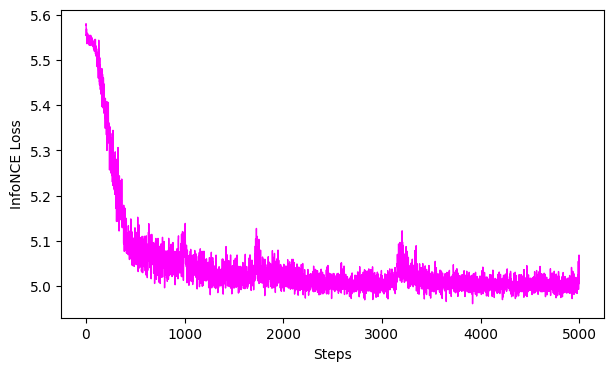

In [31]:
# Plot 3D embedding colored by label to see if the learned space separates movements
fig = cebra.integrations.plotly.plot_embedding_interactive(
    embeddings, 
    embedding_labels=y_cebra, 
    title = "EMG - Real Gestures", 
    markersize=3, 
    cmap = "rainbow")
fig.show()

# Plot the loss curve
ax = cebra.plot_loss(cebra_emg_model)

In [34]:
# Convert y_cebra labels to actual label names
label_map = get_label_mapping()
gesture_names = np.vectorize(label_map.get)(y_cebra)

# Unpack embedding into x, y, z
x, y, z = embeddings[:, 0], embeddings[:, 1], embeddings[:, 2]

# Create a 3D Scatter Plot with Colorbar for gesture names

import numpy as np
import plotly.graph_objects as go

fig = go.Figure(data=[
    go.Scatter3d(
        x=x,
        y=y,
        z=z,
        mode='markers',
        marker=dict(
            size=3,
            color=y_cebra,  # numeric labels for color
            colorscale='Rainbow',
            colorbar=dict(
                title="Gesture",
                tickvals=list(label_map.keys()),
                ticktext=list(label_map.values())
            ),
            opacity=0.8
        ),
        text=gesture_names,  
        hoverinfo='text'
    )
])

fig.update_layout(
    title="CEBRA Embedding of EMG Gestures (Colorbar = Gesture Names)",
    scene=dict(
        xaxis_title='Dim 1',
        yaxis_title='Dim 2',
        zaxis_title='Dim 3'
    )
)

fig.show()

